# Homework 11


**Concepts covered:**

pandas `DataFrame`s: grouping data, querying `DataFrame`s, joining multiple `DataFrame`s, sampling.

**Instructions:**

Be sure to run each code block after you edit it to make sure it runs as expected. When you are done, we strongly recommend you run all the code from scratch (Runtime menu -> Restart and Run all) to make sure your current code works for all problems.

If your code raises an exception when run from scratch, it will interfere with the auto-grader process causing you to lose some or all points for this homework. Please ask for help on Piazza, attend office hours or schedule an appointment with your learning facilitator if you get stuck.

**Warning about AI:**

It is **strictly forbidden to use any generative AI (e.g., ChatGPT, Claude, Gemini, CoPilot or any similar tools**) to write solutions for any assignment. Students who submit work that is not authentically their own individual work will earn a grade of 0 on this assignment.


**Docstrings and Comments:**

Include a *documentation string* (docstring) for each function definition, as well as comments in the body of your code to explain each control structures (e.g., decision, loop), function call, or formula.

## Shared Imports

Do not install or use any additional modules.
Installing additional modules may result in an autograder failure resulting in zero points for some or all problems.

In [1]:
# shared imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.close("all")


**Note: This assignment is partially manually graded, so please allow some time for you to get your final scores.**

**Review Problem 1**

**Concept:** *`DataFrame`: initialization, line plots.*

**Task:**


Using the Starbucks stock dataset:

1. Load the `SBUX.csv` dataset into a DataFrame named `df_sbux`.
2. Convert the `date` column to a pandas datetime format and set it as the index.
3. Create a line plot showing both the `high` and `low` prices over time.

Your plot should include:

* both high and low columns plotted together
* a title
* a key


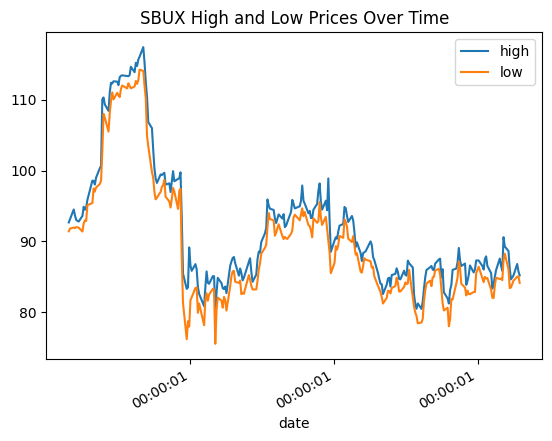

In [2]:
# Your Solution

df_SBUX = pd.read_csv("SBUX.csv")

df_SBUX["date"] = pd.to_datetime(df_SBUX["date"]) #convert date column to datetime
df_SBUX.set_index("date", inplace=True) #set date as index, inplace= True 
                                        #means we modify the original dataframe
                                        #instead of creating a new one

df_SBUX[["high", "low"]].plot() #plot high and low columns

plt.title("SBUX High and Low Prices Over Time")
plt.legend()
plt.show()


Review Problem 2

**Concept:** *`DataFrame`: initialization, descriptive statistics, histogram.*

**Task:**

Using the `SBUX.csv` dataset:

1. Load the dataset into a DataFrame named `df_sbux`.
2. Convert the `date` column to a pandas datetime format and set it as the index.
3. Compute the **daily return** of the stock using the `close` column (percentage change).
4. Display the **descriptive statistics** of the daily returns.
5. Create a **histogram** of the daily returns using 25 bins.
6. Identify **outliers** where the return falls outside of **mean ± 3 standard deviations**.
7. Print:
    *  the upper and lower bounds
    * the number of values above and below these bounds
    * the list of outlier values (sorted by date)


count    249.000000
mean      -0.000130
std        0.021601
min       -0.112162
25%       -0.011336
50%        0.000107
75%        0.011323
max        0.112812
Name: close, dtype: float64


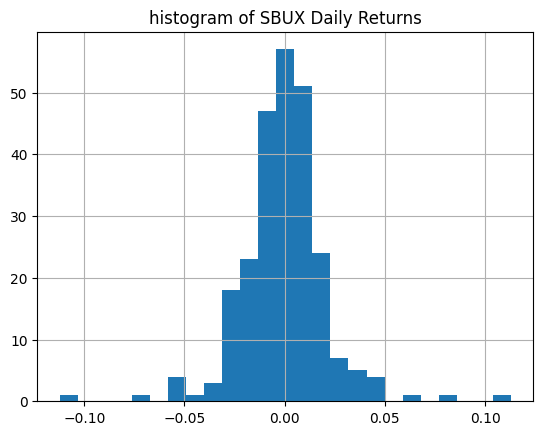

In [3]:
# Your Solution
df_SBUX = pd.read_csv("SBUX.csv")

df_SBUX["date"] = pd.to_datetime(df_SBUX["date"]) #convert date column to datetime
df_SBUX.set_index("date", inplace=True) #set date as index, inplace= True 
                                        #means we modify the original dataframe
                                        #instead of creating a new one

daily_returns = df_SBUX["close"].pct_change() #calculate daily returns 
                                                #(today-yesterday) / yesterday

print(daily_returns.describe()) #descriptive statistics

daily_returns.hist(bins=25) #plot histogram of daily returns

plt.title("histogram of SBUX Daily Returns")
plt.show()





Test case for problem 2

In [4]:
# Test Case:

mean = daily_returns.mean()
stdev = daily_returns.std()

lower = mean - 3 * stdev
upper = mean + 3 * stdev #identify outliers according to directions


above = daily_returns > upper
below = daily_returns < lower

outliers = daily_returns[above | below].sort_index() # | is the "or" operator, selects values 
                                        #that are above the upper threshold or below the lower threshold

print(outliers)

date
1970-01-01 00:00:01.738161000    0.081366
1970-01-01 00:00:01.743687000   -0.112162
1970-01-01 00:00:01.743773400   -0.069794
1970-01-01 00:00:01.744205400    0.112812
1970-01-01 00:00:01.747056600    0.066874
Name: close, dtype: float64


**Problem 3**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Load the dataset into a DataFrame named `df_weather`.
2. Convert the `datetime` column to a pandas datetime format and set it as the index.
3. Use the icon column as a categorical variable and group the data by `icon`.
4. Create a **pie chart** showing the count of each weather icon category.

Your chart should include:
* labels for each category
* a title



/tmp/ipykernel_48387/3306297586.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_weather["datetime"] = pd.to_datetime(df_weather["datetime"]) #datetime is a data type that represents dates and times


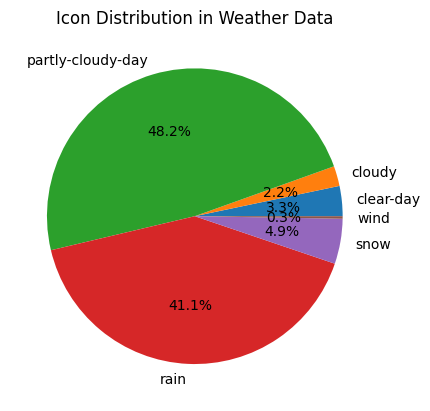

In [5]:
# Your Solution

df_weather = pd.read_csv("02215_weather.csv")

df_weather["datetime"] = pd.to_datetime(df_weather["datetime"]) #datetime is a data type that represents dates and times 
                                                        #allows for easier manipulation of date and time data
df_weather.set_index("datetime", inplace=True) # set datetime as index, inplace= True means 
                                            #we modify the original dataframe

grouped = df_weather.groupby("icon") #group by the "icon" column, which represents weather conditions
counts = grouped.size() #count the number of occurrences of each weather condition

counts.plot.pie(autopct="%1.1f%%") #plot a pie chart of the counts, autopct formats the percentage labels

plt.title("Icon Distribution in Weather Data")
plt.ylabel("") #remove y-axis label
plt.show()

**Problem 4**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Create a **histogram** of the `tempmax` column for each weather condition group.

Your plot should include:
* 25 bins
* transparency so overlapping distributions can be seen
* a legend
* a title


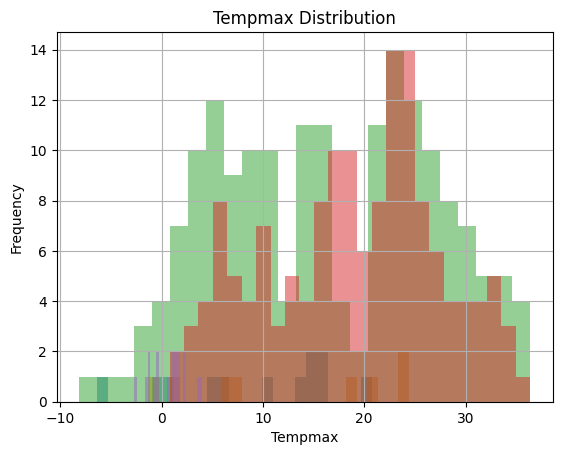

In [6]:
# Your Solution

for name, group in grouped:
    group["tempmax"].hist(bins=25, alpha=0.5, label=name) 
    # plot histogram of tempmax for each weather condition, alpha controls transparency 
    # #label is the legend label

plt.title("Tempmax Distribution")
plt.xlabel("Tempmax")
plt.ylabel("Frequency")
plt.show()


**Problem 5**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Create a histogram of the `precip` column for each weather condition group.

Your plot should include:

* 10 bins
* transparency so overlapping distributions can be seen
* a legend
* a title



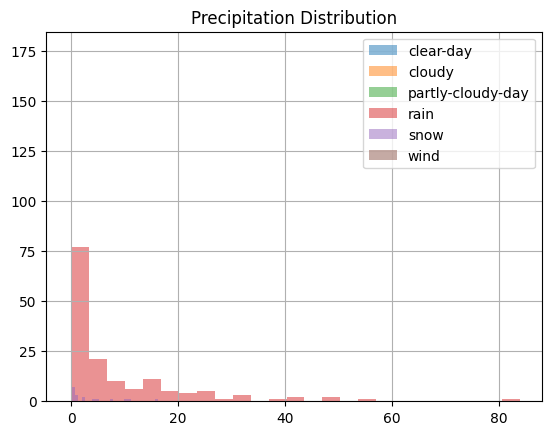

In [7]:
# Your Solution

for name,group in grouped:
    group["precip"].hist(bins=25, alpha=0.5, label=name)
    #plot histogram of precip for each weather condition, alpha controls transparency
    #label is the legend label

plt.title("Precipitation Distribution")
plt.legend()
plt.show()

**Problem 6**

**Concept:** *Grouping Data, plotting*


**Task:**


Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Compute the **mean** of the `tempmax` column for each weather condition group.
3. Create a **bar chart** to display the mean maximum temperature for each group.


Your plot should include:

* one bar for each weather icon category
* a title



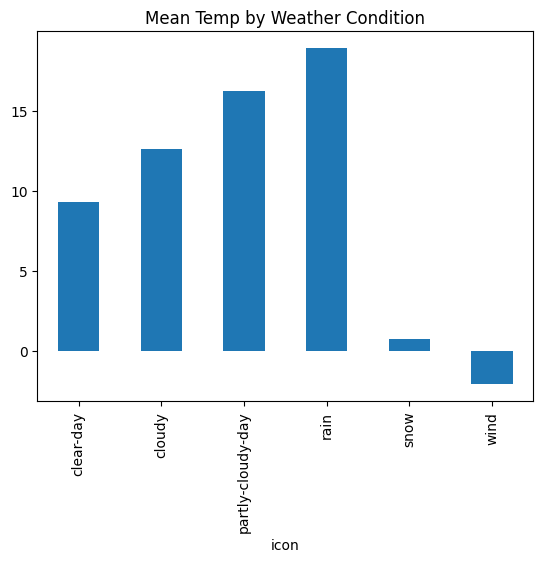

In [8]:
# Your Solution

temperature = df_weather.groupby("icon")["tempmax"].mean() #calculate mean of tempmax column

temperature.plot.bar() #plot mean temperature as a bar chart

plt.title("Mean Temp by Weather Condition")
plt.show()


**Problem 7**

**Concept:** *Grouping data, descriptive statistics*


**Task:**

Using the `02215_weather.csv` dataset:

1. Group the DataFrame by the `icon` column and store the result in a variable named `grouped_by_icon`.
2. Compute descriptive statistics for the `tempmax` column for each group and store the result in a variable named `grouped_tempmax_statistics`.
3. Compute descriptive statistics for the `precip` column for each group and store the result in a variable named `grouped_precipitation_statistics`.
4. Compute the **mean** of the `tempmax` column for each group and store the result in a variable named `grouped_tempmax_mean`.

Print all three results with clear labels:
* `"Tempmax grouped by conditions"`
* `"Precipitation grouped by conditions"`
* `"Mean of tempmax grouped by conditions"`


In [9]:
# Your Solution

grouped_by_icon = df_weather.groupby("icon") #group by the "icon" column
                                            #which represents weather conditions

grouped_tempmax_statistics = grouped_by_icon["tempmax"].describe() #descriptive statistics of tempmax for each weather condition
grouped_precipitation_statistics = grouped_by_icon["precip"].describe() #descriptive statistics of precip for each weather condition
grouped_tempmax_mean = grouped_by_icon["tempmax"].mean() #mean of tempmax for each weather condition

print("Tempmax grouped by conditions")
print(grouped_tempmax_statistics)

print("\nPrecipitation grouped by conditions")
print(grouped_precipitation_statistics)

print("\nMean of tempmax grouped by conditions")
print(grouped_tempmax_mean)



Tempmax grouped by conditions
                   count       mean        std  min    25%    50%     75%  \
icon                                                                        
clear-day           12.0   9.316667   8.230965 -6.4   4.15  12.10  15.225   
cloudy               8.0  12.575000  10.423565 -1.3   4.95  13.05  21.350   
partly-cloudy-day  176.0  16.246023  10.533554 -8.1   7.20  15.65  25.000   
rain               150.0  18.904000   8.498037  0.8  12.60  19.90  24.600   
snow                18.0   0.750000   1.805628 -2.7  -0.65   1.25   1.775   
wind                 1.0  -2.100000        NaN -2.1  -2.10  -2.10  -2.100   

                    max  
icon                     
clear-day          20.8  
cloudy             24.4  
partly-cloudy-day  36.4  
rain               36.4  
snow                4.0  
wind               -2.1  

Precipitation grouped by conditions
                   count      mean        std    min      25%     50%  \
icon                               

QUERYING

The following data frame will be used in several questions.


In [10]:
# starter code
df_voter_data = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-11/newton_voters.csv", low_memory=False)
df_voter_data.index = df_voter_data["Voter ID Number"]
df_voter_data['Date of Birth'] = pd.to_datetime(df_voter_data['Date of Birth'])


**Problem 8**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Determine the **total number of voters** and print the result.
2. Compute the count of voters in each **Party Affiliation** category.
3. Create a **pie chart** showing the distribution of voters by party affiliation.

Your plot should include:
* labels for each category
* a title that includes the total number of voters


58769


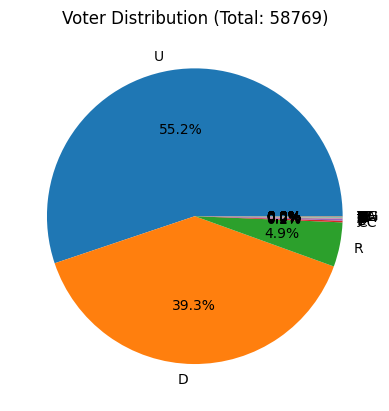

In [18]:
# Your Solution

total_voters = len(df_voter_data) #total number of voters is the length of the dataframe
print(total_voters)

party_members = df_voter_data["Party Affiliation"].value_counts() #count the number of voters
                                                                #for each party affiliation
party_members.plot.pie(autopct="%1.1f%%") #plot a pie chart of the counts

plt.title(f"Voter Distribution (Total: {total_voters})")
plt.show()


**Problem 9**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Create a new DataFrame named `df_older_voters` that includes only voters born **before January 1, 1950**.
    * Use the `.query()` method
    * Note: use backticks for column names containing spaces
2. Print the total number of voters in this filtered dataset.
3. Compute the count of voters in each **Party Affiliation** category for this subset.
4. Create a **pie chart** showing the distribution of party affiliations among these older voters.

Your plot should include:
* labels for each category
* a title that includes the number of older voters


9073


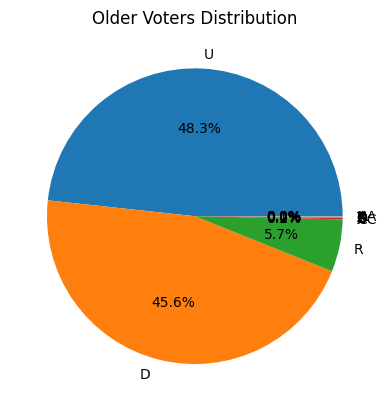

In [20]:
# Your Solution

df_older_voters = df_voter_data.query("`Date of Birth` < '1950-01-01'")

print(len(df_older_voters))

counts = df_older_voters["Party Affiliation"].value_counts()

counts.plot.pie(autopct="%1.1f%%")

plt.title("Older Voters Distribution")
plt.show()



**Problem 10**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Create a new DataFrame named `df_younger_voters` that includes only voters born **after January 1, 2000**.
    * Use the `.query()` method
    * Note: use backticks for column names containing spaces
2. Print the total number of voters in this filtered dataset.
3. Compute the count of voters in each **Party Affiliation** category for this subset.
4. Create a **pie chart** showing the distribution of party affiliations among these Younger voters.

Your plot should include:
* labels for each category
* a title that includes the number of younger voters


5099


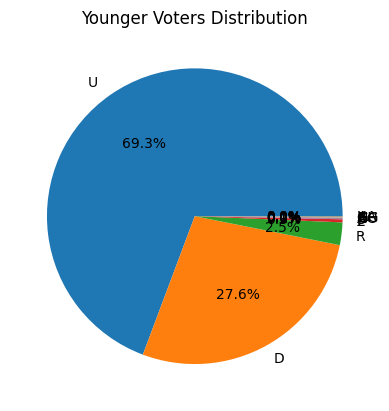

In [21]:
# Your Solution

df_younger_voters = df_voter_data.query("`Date of Birth` > '2000-01-01'")

print(len(df_younger_voters))

counts = df_younger_voters["Party Affiliation"].value_counts()

counts.plot.pie(autopct="%1.1f%%")

plt.title("Younger Voters Distribution")
plt.show()



**Problem 11**

**Concept:** *Querying `DataFrame`s and graphing*



**Task:**

Using the `df_voter_data` DataFrame:
1. Identify all columns related to elections:
    * Select columns whose names contain the letter `"v"` but do **not** contain `"score"`
    * Store the result in a variable named `election_columns`

2. Compute the **voting participation percentage** for each election among all voters:
    * Store the result in a variable named `d1`
    * **Hint:** To calculate participation
        * Use `.sum()` on a column to count how many voters participated
        * Divide by the total number of voters using `len(df)`
        * Multiply by 100 to convert to a percentage

3. Create a filtered DataFrame named `df_high_voter_score`:
    * Include only voters with `voter_score >= 4`
    * Print the number of voters in this group

4. Compute the **voting participation percentage** for this group:
    * Store the result in a variable named `d2`

5. Create a filtered DataFrame named `df_unenrolled`:
    * Include only voters with `"Party Affiliation" == "U "`
    * Print the number of voters in this group

6. Compute the voting participation percentage for this group:
    * Store the result in a variable named `d3`

7. Combine the results into a new DataFrame named `d`:
    * Index should be the election columns
    * Columns should be:
        * `"all voters"`
        * `"high-propensity voters"`
        * `"unenrolled voters"`

8. Create a **bar chart** from this combined DataFrame.

Your plot should include:
* a title
* a key

High propensity voter count: 15245
Unenrolled voter count: 32416


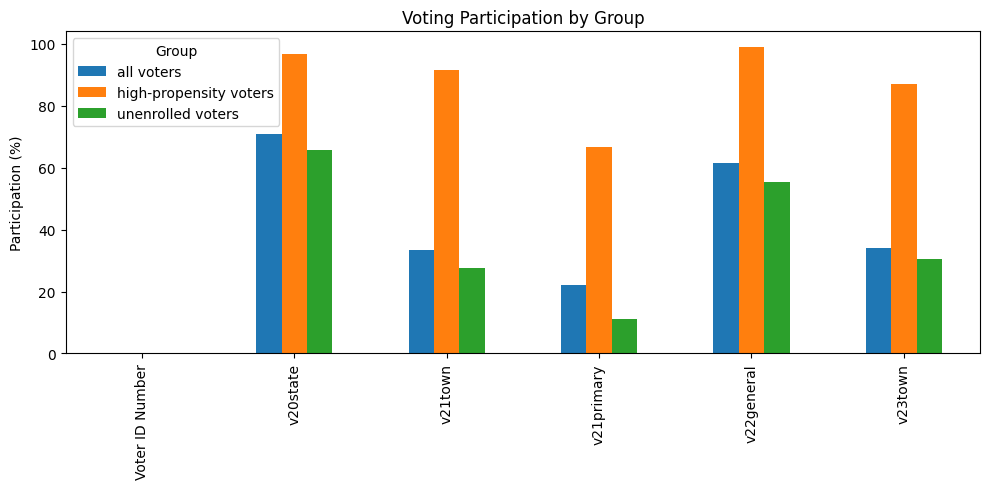

In [ ]:
# Your Solution

election_columns = [
    col for col in df_voter_data.columns
    if ("v" in col.lower()) and ("score" not in col.lower())
]   #identify correct columns for problem 11

df_voter_data[election_columns] = df_voter_data[election_columns].apply(pd.to_numeric, errors="coerce").fillna(0)
#convert election columns to numeric, errors="coerce" will convert non-numeric values to NaN, fillna(0) will replace NaN with 0

d1 = (df_voter_data[election_columns].sum() / len(df_voter_data)) * 100 
#overall participation percentage, sum of votes divided by total voters, multiplied by 100

df_high_voter_score = df_voter_data[df_voter_data["voter_score"] >= 4]
print("High propensity voter count:", len(df_high_voter_score)) #voter score of 4 or higher

d2 = (df_high_voter_score[election_columns].sum() / len(df_high_voter_score)) * 100
#participation percentage for high score voters

df_unenrolled = df_voter_data[df_voter_data["Party Affiliation"] == "U "]
print("Unenrolled voter count:", len(df_unenrolled))

d3 = (df_unenrolled[election_columns].sum() / len(df_unenrolled)) * 100
#participation percentage for unenrolled voters


d = pd.DataFrame({"all voters": d1, "high-propensity voters": d2, "unenrolled voters": d3})

ax = d.plot(kind="bar", figsize=(10, 5), title="Voting Participation by Group")
ax.set_ylabel("Participation (%)")
ax.legend(title="Group")

plt.tight_layout() #adjust layout to prevent overlap
plt.show()



**Problem 12**

**Concept:** *Joining `DataFrame`s*


**Task:**

You are given two DataFrames:
* `submissions`, which contains student IDs and their homework submission IDs
* `grades`, which contains homework grades indexed by submission ID

Using these DataFrames:
1. Inspect both DataFrames by printing them.
2. Join the `submissions` DataFrame with the `grades` DataFrame:
    * Match the `hw1_submission` column in `submissions` with the index of `grades`
    * Store the result in a variable named `result`
3. Update the index of the resulting DataFrame:
    * Set the index to the `student_id` column
4. Create a new DataFrame named `result_df`:
    * Remove the `student_id` column
5. Print the final DataFrame


Starter code:

In [24]:
# STARTER CODE:
submissions = pd.DataFrame(data={"student_id": ["U100", "U101", "U102", "U103", "U104"],
                        "hw1_submission": ["c1325", "b231", "a512", "e9999", "d8234"]})

grades = pd.DataFrame(index=["a512", "b231", "c1325", "d8234", "e9999"],
                        data={"hw1_grade": [0.99, 0.50, 0.62, 0.78, 1.00]} )


In [25]:
# Your Solution

print(submissions)
print(grades)

result = submissions.join(grades, on="hw1_submission") #join grades to submissions based on hw1_submission column 
                                                        #which matches the index of grades

result = result.set_index("student_id") # set student_id as index for the final result

result_df = result.copy() #create a copy of the result dataframe to avoid modifying the original

print(result_df)

  student_id hw1_submission
0       U100          c1325
1       U101           b231
2       U102           a512
3       U103          e9999
4       U104          d8234
       hw1_grade
a512        0.99
b231        0.50
c1325       0.62
d8234       0.78
e9999       1.00
           hw1_submission  hw1_grade
student_id                          
U100                c1325       0.62
U101                 b231       0.50
U102                 a512       0.99
U103                e9999       1.00
U104                d8234       0.78


**Problem 13**

**Concept:** *Joining `DataFrame`s*



**Task:**

You are given two datasets:
* `design_materials.tsv`, which contains materials and the quantity required per bed
* `material_costs.tsv`, which contains the cost per unit for each material

Using these datasets:
1. Load both datasets from the provided `.tsv` files using the correct separator.
2. Merge the two DataFrames:
    * Join on the `material` column
    * Store the result in a variable named `df_costs`
3. Create a new column named `cost`:
    * Compute it as:

      **quantity_per_bed × unit_cost**
4. Print the resulting DataFrame

In [26]:
# Your Solution

design_materials = pd.read_csv("design_materials.tsv", sep="\t")

material_costs = pd.read_csv("material_costs.tsv", sep="\t")
#print(design_materials)

df_costs = pd.merge(design_materials, material_costs, on="material")
#merge design_materials and material_costs on the "material" column, which is common to both dataframes

df_costs["cost"] = df_costs["quantity_per_bed"] * df_costs["unit_cost"]
#calculate total cost for each material by multiplying quantity_per_bed by unit_cost

print(df_costs)



          design                    material  quantity_per_bed  unit_cost  \
0  4' x 4' x 18"                2" x 6" x 4'                20       5.92   
1  4' x 4' x 18"  8" x 8" x 16" Cinder Block                12       3.53   
2  4' x 8' x 18"                2" x 6" x 4'                 6       5.92   
3  4' x 8' x 18"                2" x 6" x 8'                14       7.62   
4  4' x 8' x 18"  8" x 8" x 16" Cinder Block                24       3.53   
5  4' x 4' x 12"                2" x 6" x 4'                16       5.92   
6  4' x 4' x 12"  8" x 8" x 16" Cinder Block                12       3.53   
7  4' x 8' x 12"                2" x 6" x 4'                 2       5.92   
8  4' x 8' x 12"                2" x 6" x 8'                12       7.62   
9  4' x 8' x 12"  8" x 8" x 16" Cinder Block                24       3.53   

     cost  
0  118.40  
1   42.36  
2   35.52  
3  106.68  
4   84.72  
5   94.72  
6   42.36  
7   11.84  
8   91.44  
9   84.72  


**Problem 14**

**Concept:** *joining `DataFrame`s*


**Task:**

You are given three stock datasets:
* BAC
* GM
* SBUX

Using these datasets:
1. Load each dataset into separate DataFrames:
    * `df_bac`, `df_gm`, and `df_sbux`
2. Convert the `date` column in each DataFrame to pandas datetime format and set it as the index.
3. Create a new DataFrame named `df_stock_prices`:
    * Use the index from `df_bac`
    * Add the following columns:
        * `"bac"` from `df_bac["close"]`
        * `"gm"` from `df_gm["close"]`
        * `"sbux"` from `df_sbux["close"]`
4. Create a **line plot** showing the stock prices over time.

Your plot should include:
* all three stocks on the same chart
* a title

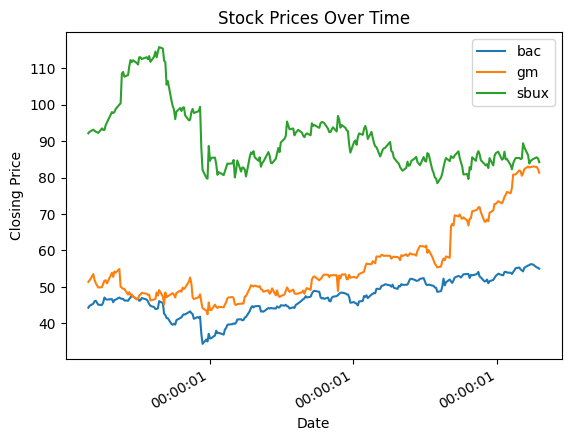

In [28]:
# Your Solution

df_bac = pd.read_csv("BAC.csv")

df_gm = pd.read_csv("GM.csv")

df_sbux = pd.read_csv("SBUX.csv")
#read csvs

df_bac["date"] = pd.to_datetime(df_bac["date"])

df_gm["date"] = pd.to_datetime(df_gm["date"])

df_sbux["date"] = pd.to_datetime(df_sbux["date"])
#convert date columns to datetime

df_bac = df_bac.set_index("date")

df_gm = df_gm.set_index("date")

df_sbux = df_sbux.set_index("date")
#set date as index for each dataframe

df_stock_prices = pd.DataFrame(index=df_bac.index)

df_stock_prices["bac"] = df_bac["close"]

df_stock_prices["gm"] = df_gm["close"]

df_stock_prices["sbux"] = df_sbux["close"]
#create a new dataframe with date as index and close prices for each stock as columns

df_stock_prices.plot(title="Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()



**Problem 15**

**Concept:** *joining `DataFrame`s*


**Task:**

Using the `df_stock_prices` DataFrame from **Problem 14**:
1. Compute the **relative prices** of each stock:
    * Divide all values by the first row of the DataFrame
    * Store the result in a variable named `df_stock_prices_relative`
2. Create a **line plot** of the relative prices.

Your plot should include:
* all three stocks on the same chart
* a title

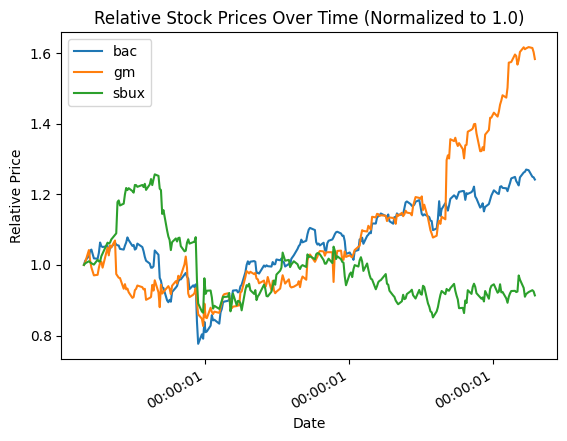

In [30]:
# Your Solution

df_stock_prices_relative = df_stock_prices / df_stock_prices.iloc[0]
#normalize stock prices by dividing each price by the first price in the dataframe

df_stock_prices_relative.plot(title="Relative Stock Prices Over Time (Normalized to 1.0)")
plt.xlabel("Date")
plt.ylabel("Relative Price")
plt.show()

